## IMPORTS

In [1]:
import os
import scanpy as sc
import decoupler as dc
import liana as li
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation    
import scrublet as scr
import scanpy.external as sce
import pertpy as pt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import itertools
from pydeseq2.default_inference import DefaultInference
from joblib import parallel_backend
import traceback
import scipy.sparse as sp
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

os.makedirs('../figures', exist_ok=True)
sc.set_figure_params(dpi=100, frameon=False, vector_friendly=True)

/home/bioinf2026/mirny/miniconda3/envs/scanpy_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reading data

In [2]:
adata = sc.read_h5ad('../data/adata_qc.h5ad')
adata.layers['counts'] = adata.X.copy()
print(adata)
print("var index name:", adata.var.index.name)
print("var columns:", adata.var.columns.tolist()[:5])

AnnData object with n_obs × n_vars = 98976 × 19027
    obs: 'donor_id', 'sex_ontology_term_id', 'cell_type_ontology_term_id', 'luad_histologic_subtype', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'author_cell_type_level_1', 'author_cell_type_level_2', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'is_doublet'
    var: 'gene_symbol', 'feature_is_filtered', 'feature_name', 'feature_reference

## Binary EGFR division

In [3]:
egfr_status = {
    'KNUH01': 'Non-Indel',
    'KNUH02': 'Indel',
    'KNUH03': 'Non-Indel',
    'KNUH04': 'Indel',
    'KNUH05': 'Indel',
    'KNUH06': 'Non-Indel',
    'KNUH07': 'Indel',
    'KNUH08': 'Non-Indel',
    'KNUH09': 'Non-Indel',
    'KNUH11': 'Indel',
    'KNUH12': 'Non-Indel',
    'KNUH13': 'Indel',
    'KNUH14': 'Non-Indel',
    'KNUH16': 'Non-Indel',
    'KNUH18': 'Indel',
    'KNUH19': 'Non-Indel',
    'KNUH20': 'Non-Indel',
    'KNUH22': 'Indel',
}

adata.obs['egfr_status_bin'] = adata.obs['donor_id'].map(egfr_status)

print(adata.obs['egfr_status_bin'].value_counts())
print('NaN:', adata.obs['egfr_status_bin'].isna().sum())

egfr_status_bin
Non-Indel    54369
Indel        44607
Name: count, dtype: int64
NaN: 0


## DE via pyDESeq2

In [4]:
inference = DefaultInference(n_cpus=1)

compartments = ['Myeloid', 'Lymphoid', 'Stroma']
subtypes_present = adata.obs['egfr_status_bin'].dropna().unique().tolist()
pairs = list(itertools.combinations(subtypes_present, 2))

print(f"EGFR-statuses: {subtypes_present}")

all_results_by_egfr_bin = {}

for comp in compartments:
    all_results_by_egfr_bin[comp] = {}
    subset = adata[
        (adata.obs['cell_group'] == comp) &
        (adata.obs['egfr_status_bin'].notna())
    ].copy()
    
    for (st1, st2) in pairs:
        print(f"\n--- {comp}: {st1} vs {st2} ---")
        sub = subset[subset.obs['egfr_status_bin'].isin([st1, st2])].copy()
        
        ps = pt.tl.PseudobulkSpace()
        pdata = ps.compute(
            sub,
            target_col='donor_id',
            groups_col=None,
            layer_key='counts',
            mode='sum'
        )
        
        donor_status = sub.obs[['donor_id','egfr_status_bin']]\
            .drop_duplicates().set_index('donor_id')
        pdata.obs['egfr_status_bin'] = pdata.obs.index.map(
            donor_status['egfr_status_bin']
        )
        pdata = pdata[pdata.obs['egfr_status_bin'].notna()].copy()
        
        if pdata.obs['egfr_status_bin'].nunique() < 2:
            print(f"  Skipped")
            continue
        
        sc.pp.filter_genes(pdata, min_cells=3)
        
        counts_df = pd.DataFrame(
            pdata.X.astype(int),
            index=pdata.obs_names,
            columns=pdata.var_names
        )
        metadata = pdata.obs[['egfr_status_bin']].copy()
        
        with parallel_backend('sequential'):
            dds = DeseqDataSet(
                counts=counts_df,
                metadata=metadata,
                design_factors='egfr_status_bin',
                ref_level=['egfr_status_bin', st2],
                inference=inference
            )
            dds.deseq2()
            stat_res = DeseqStats(
                dds,
                contrast=['egfr_status_bin', st1, st2],
                inference=inference
            )
            stat_res.summary()
        
        res = stat_res.results_df.copy()
        res = res.dropna(subset=['padj'])
        res_sig = res[
            (res['padj'] < 0.05) & (res['log2FoldChange'].abs() > 1)
        ].sort_values('padj')
        
        print(f"  DEG: {len(res_sig)}")
        all_results_by_egfr_bin[comp][(st1, st2)] = {
           'full': res.copy(),
           'sig':  res_sig.copy()
       }

print("\nDone.")

EGFR-statuses: ['Non-Indel', 'Indel']

--- Myeloid: Non-Indel vs Indel ---


/tmp/ipykernel_265285/251365481.py:52: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_265285/251365481.py:52: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 19.09 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 22.64 seconds.

Fitting LFCs...
... done in 15.71 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 107 outlier genes.

Fitting dispersions...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.13 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Running Wald tests...
... done in 2.49 seconds.



Log2 fold change & Wald test p-value: egfr_status_bin Non-Indel vs Indel
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
LINC01409    36.386347        0.129610  0.232947  0.556393  0.577942  0.999897
FAM87B        2.066241       -0.447390  0.681782 -0.656207  0.511691  0.999897
LINC01128   116.916287       -0.256213  0.194751 -1.315595  0.188310  0.999897
LINC00115     9.128404        0.306021  0.397548  0.769772  0.441435  0.999897
FAM41C       11.882239       -0.263218  0.404339 -0.650984  0.515057  0.999897
...                ...             ...       ...       ...       ...       ...
MT-ND4L    1012.611131        0.049558  0.157753  0.314152  0.753406  0.999897
MT-ND4     3799.666745        0.046948  0.130016  0.361093  0.718030  0.999897
MT-ND5     2324.487236        0.003099  0.148072  0.020927  0.983304  0.999897
MT-ND6      316.876711       -0.165355  0.291785 -0.566700  0.570918  0.999897
MT-CYB     3587.859673        0.062390  0.134199  0.464905

...

/tmp/ipykernel_265285/251365481.py:52: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_265285/251365481.py:52: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 15.28 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 19.17 seconds.

Fitting LFCs...
... done in 16.85 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 29 outlier genes.

Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: egfr_status_bin Non-Indel vs Indel
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
LINC01409    2.267978        0.772944  0.594477  1.300208  0.193530       NaN
FAM87B       0.240163       -0.709629  2.870343 -0.247228  0.804732       NaN
LINC01128   10.523752       -0.109622  0.283335 -0.386899  0.698831  0.968808
LINC00115    0.917554        0.310323  0.794776  0.390454  0.696201       NaN
FAM41C       1.283015        0.220757  1.076386  0.205091  0.837501       NaN
...               ...             ...       ...       ...       ...       ...
MT-ND4L    133.757596        0.219690  0.188394  1.166121  0.243566  0.817635
MT-ND4     469.062384        0.120467  0.120362  1.000872  0.316889  0.847457
MT-ND5     308.286137        0.110388  0.122281  0.902742  0.366663  0.876234
MT-ND6      37.290069       -0.097432  0.292523 -0.333074  0.739079  0.968808
MT-CYB     470.567817        0.134826  0.121269  1.111792  0.266228  

... done in 2.31 seconds.



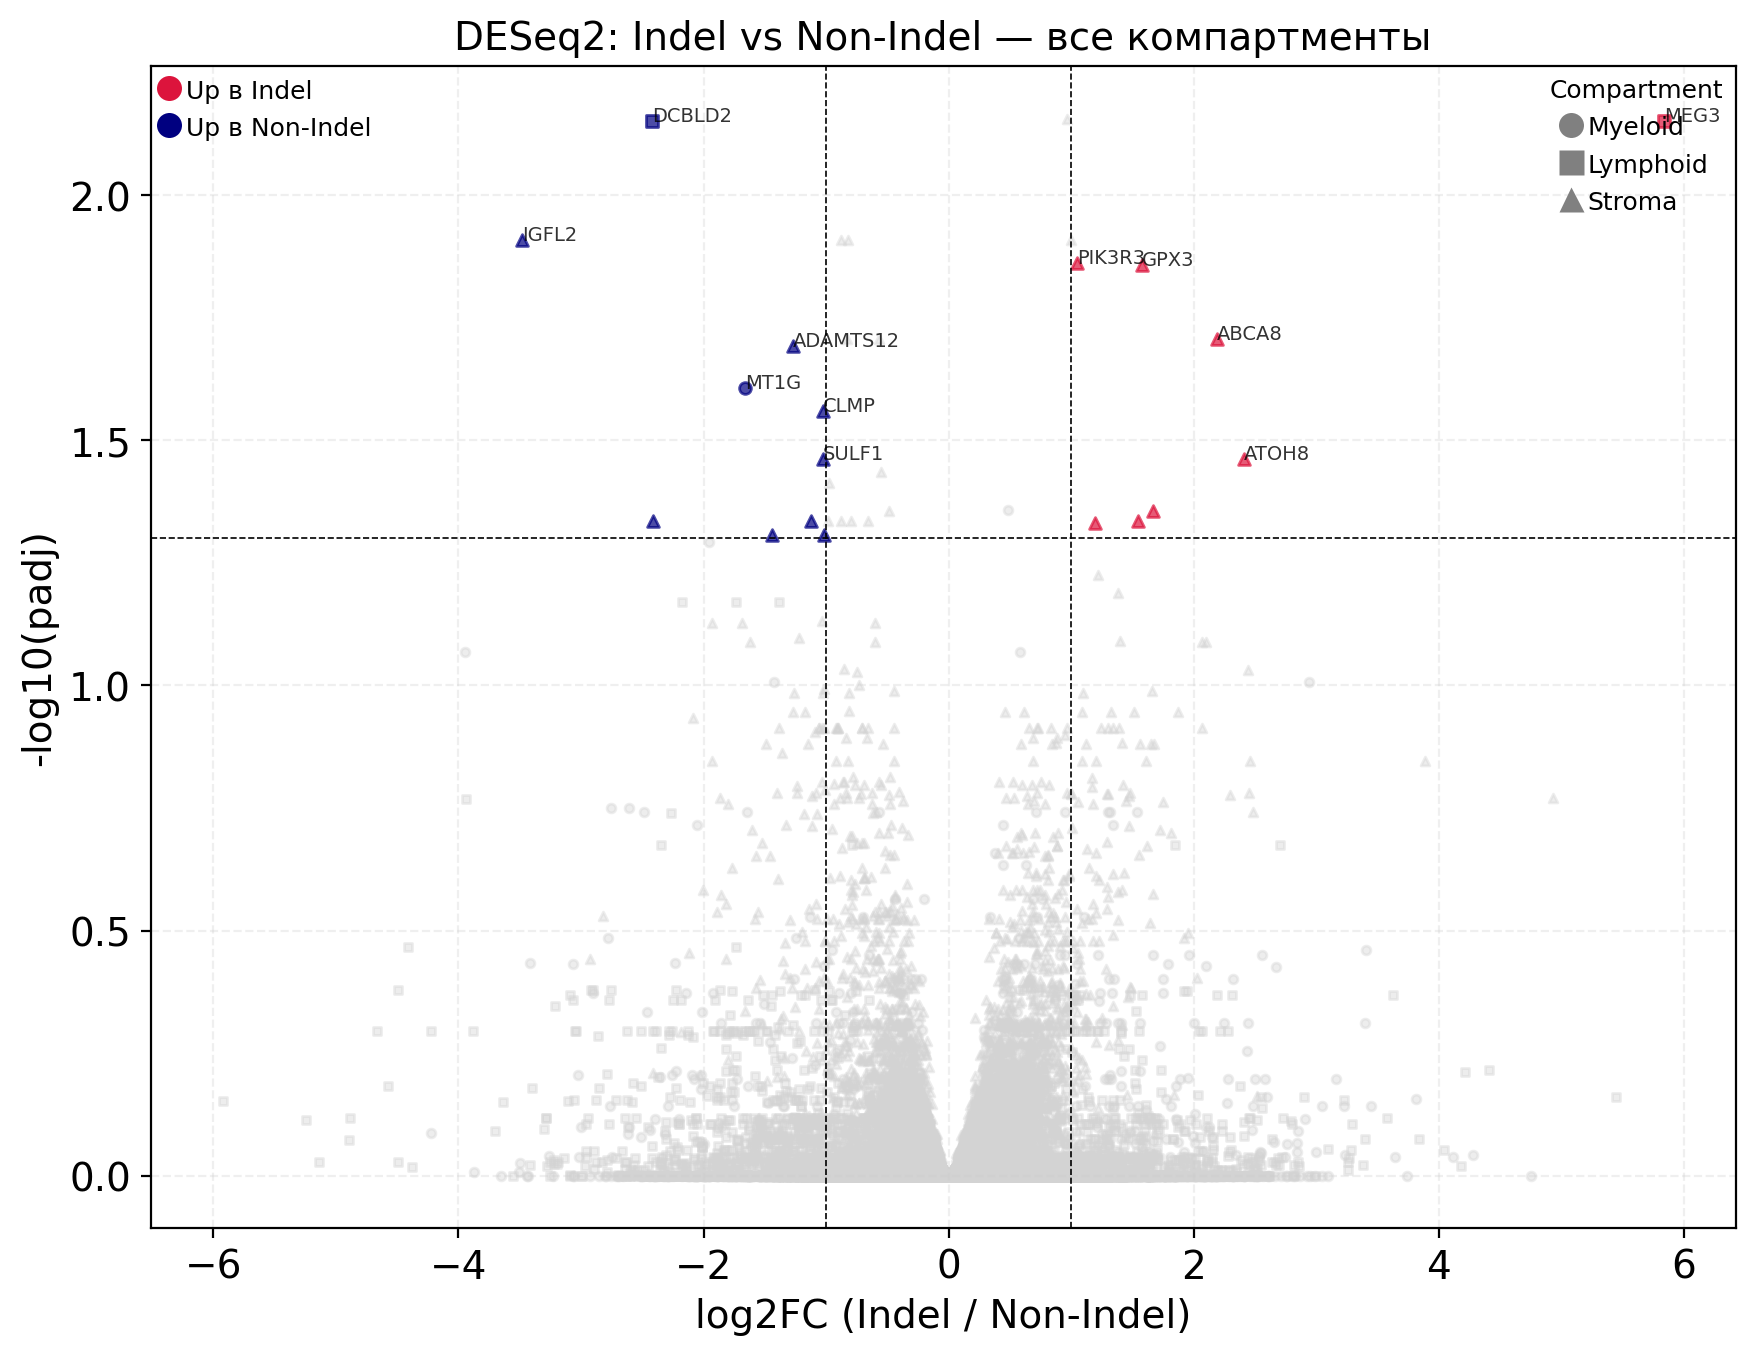

deseq2_indel_vs_nonindel_summary.txt saved


In [5]:
marker_map = {'Myeloid': 'o', 'Lymphoid': 's', 'Stroma': '^'}

fig, ax = plt.subplots(figsize=(9, 7))

for comp, pairs_dict in all_results_by_egfr_bin.items():
    for (st1, st2), res_dict in pairs_dict.items():
        res = res_dict['full'].copy()
        if res.empty:
            continue
        
        res['-log10padj'] = -np.log10(res['padj'].replace(0, 1e-300))
        res['significant'] = (res['padj'] < 0.05) & (res['log2FoldChange'].abs() > 1)
        
        m = marker_map.get(comp, 'o')
        
        ax.scatter(
            res.loc[~res['significant'], 'log2FoldChange'],
            res.loc[~res['significant'], '-log10padj'],
            c='lightgrey', s=10, alpha=0.4, marker=m
        )
        ax.scatter(
            res.loc[res['significant'] & (res['log2FoldChange'] > 0), 'log2FoldChange'],
            res.loc[res['significant'] & (res['log2FoldChange'] > 0), '-log10padj'],
            c='crimson', s=18, alpha=0.7, marker=m
        )
        ax.scatter(
            res.loc[res['significant'] & (res['log2FoldChange'] < 0), 'log2FoldChange'],
            res.loc[res['significant'] & (res['log2FoldChange'] < 0), '-log10padj'],
            c='navy', s=18, alpha=0.7, marker=m
        )
        
        top_label = res[res['significant']].nsmallest(8, 'padj')
        for gene, row in top_label.iterrows():
            ax.annotate(gene, (row['log2FoldChange'], row['-log10padj']),
                        fontsize=7, alpha=0.8)

ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.6)
ax.axvline(1,  color='black', linestyle='--', linewidth=0.6)
ax.axvline(-1, color='black', linestyle='--', linewidth=0.6)

ax.set_xlabel('log2FC (Indel / Non-Indel)')
ax.set_ylabel('-log10(padj)')
ax.set_title('DESeq2: Indel vs Non-Indel — все компартменты')
ax.grid(True, linestyle='--', alpha=0.3)

color_legend = [
    mlines.Line2D([], [], marker='o', linestyle='None', markerfacecolor='crimson',
                  markeredgecolor='none', markersize=9, label='Up в Indel'),
    mlines.Line2D([], [], marker='o', linestyle='None', markerfacecolor='navy',
                  markeredgecolor='none', markersize=9, label='Up в Non-Indel'),
]
shape_legend = [
    mlines.Line2D([], [], marker=m, linestyle='None', markerfacecolor='grey',
                  markeredgecolor='none', markersize=9, label=comp)
    for comp, m in marker_map.items()
]

leg1 = ax.legend(handles=color_legend, loc='upper left', frameon=False, fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=shape_legend, loc='upper right', frameon=False, fontsize=9,
          title='Compartment', title_fontsize=9)

plt.tight_layout()
plt.savefig('../figures/volcano_combined_indel_vs_nonindel.png', dpi=200, bbox_inches='tight')
plt.show()

with open('../figures/deseq2_indel_vs_nonindel_summary.txt', 'w', encoding='utf-8') as f:
    for comp, pairs_dict in all_results_by_egfr_bin.items():
        for (st1, st2), res_dict in pairs_dict.items():
            sig = res_dict['sig']
            f.write(f'=== {comp}: {st1} vs {st2} ===\n')
            f.write(f'Total DEG (padj<0.05, |log2FC|>1): {len(sig)}\n')
            
            up = sig[sig['log2FoldChange'] > 0]
            down = sig[sig['log2FoldChange'] < 0]
            f.write(f'  Up in {st1}: {len(up)}\n')
            f.write(f'  Up in {st2}: {len(down)}\n\n')
            
            f.write(f'Топ-10 Up in {st1}:\n')
            for gene, row in up.head(10).iterrows():
                f.write(f'  {gene}: log2FC={row["log2FoldChange"]:.2f}, '
                        f'padj={row["padj"]:.2e}\n')
            
            f.write(f'\nТоп-10 Up in {st2}:\n')
            for gene, row in down.head(10).iterrows():
                f.write(f'  {gene}: log2FC={row["log2FoldChange"]:.2f}, '
                        f'padj={row["padj"]:.2e}\n')
            f.write('\n')

print('deseq2_indel_vs_nonindel_summary.txt saved')

## Cell-cell communication analysis via LIANA+

In [6]:
subtypes = adata.obs['egfr_status_bin'].dropna().unique().tolist()
liana_results = []

for st in subtypes:
    adata_sub = adata[adata.obs['egfr_status_bin'] == st].copy()
    if adata_sub.n_obs < 100:
        continue

    group_counts = adata_sub.obs['cell_group'].value_counts()
    valid_groups = group_counts[group_counts >= 5].index.tolist()
    if len(valid_groups) < 2:
        print(f"Skipping {st}: <2 valid cell_group")
        continue

    adata_sub = adata_sub[adata_sub.obs['cell_group'].isin(valid_groups)].copy()

    print(f"Calculating for {st}: {adata_sub.n_obs} cells, {adata_sub.n_vars} genes")

    try:
        li.mt.rank_aggregate(
            adata_sub,
            groupby='cell_group',
            expr_prop=0.1,
            min_cells=5,
            use_raw=False,
            verbose=True,
            inplace=True
        )
        res = adata_sub.uns['liana_res'].copy()
        res['egfr_status_bin'] = st
        liana_results.append(res)
        print(f"{st}: OK, {len(res)} interactions")

    except Exception as e:
        print(f"\n!!! Ошибка для {st}: {type(e).__name__}: {e}")
        traceback.print_exc()
        continue

if liana_results:
    full_liana_by_egfr_bin = pd.concat(liana_results)
    print(f"\nDone. Total interactions: {len(full_liana_by_egfr_bin)}")
    print(full_liana_by_egfr_bin.head())
else:
    print("\nliana_results is empty")

2026-05-21 21:50:32 | [INFO] Using resource `consensus`.
2026-05-21 21:50:32 | [INFO] Using `.X`!


Calculating for Non-Indel: 54369 cells, 19027 genes


2026-05-21 21:50:32 | [WARNING] 3 features of mat are empty, they will be removed.
/home/bioinf2026/mirny/miniconda3/envs/scanpy_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
2026-05-21 21:50:44 | [INFO] 0.12 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 54369 samples and 1598 features


/home/bioinf2026/mirny/miniconda3/envs/scanpy_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/bioinf2026/mirny/miniconda3/envs/scanpy_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


...

Generating ligand-receptor stats for 44607 samples and 1597 features


/home/bioinf2026/mirny/miniconda3/envs/scanpy_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/bioinf2026/mirny/miniconda3/envs/scanpy_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:53<00:00, 18.63it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
Indel: OK, 6399 interactions

Done. Total interactions: 12000
        source    target ligand_complex receptor_complex  lr_means  \
1885    Stroma  Lymphoid          HMGB1            CXCR4  2.529886   
2373    Stroma   Myeloid          TIMP1             CD63  2.505594   
2914    Stroma    Stroma          TIMP1             CD63  2.502493   
462   Lymphoid     Tumor          HLA-A            APLP2  2.476274   
2407    Stroma   Myeloid            VIM             CD44  2.533446   

      cellphone_pvals  expr_prod  scaled_weight  lr_logfc  spec_weight  \
1885              0.0   6.117360       0.433432  1.488684     0.161865   
2373              0.0   6.275405       1.193387  2.319258     0.146109   
2914              0.0   6.259554       1.190854  2.182550     0.145740   
462               0.0   5.594299       0.589722  0.965029     0.111706   
2407              0.0   5.370127       0.667270  0.859925     0.126104   

Significant interactions: 9465
egfr_status_bin
Indel        4932
Non-Indel    4533
dtype: int64
Total Tumor → TME interactions: 2062
egfr_status_bin
Indel        1092
Non-Indel     970
dtype: int64


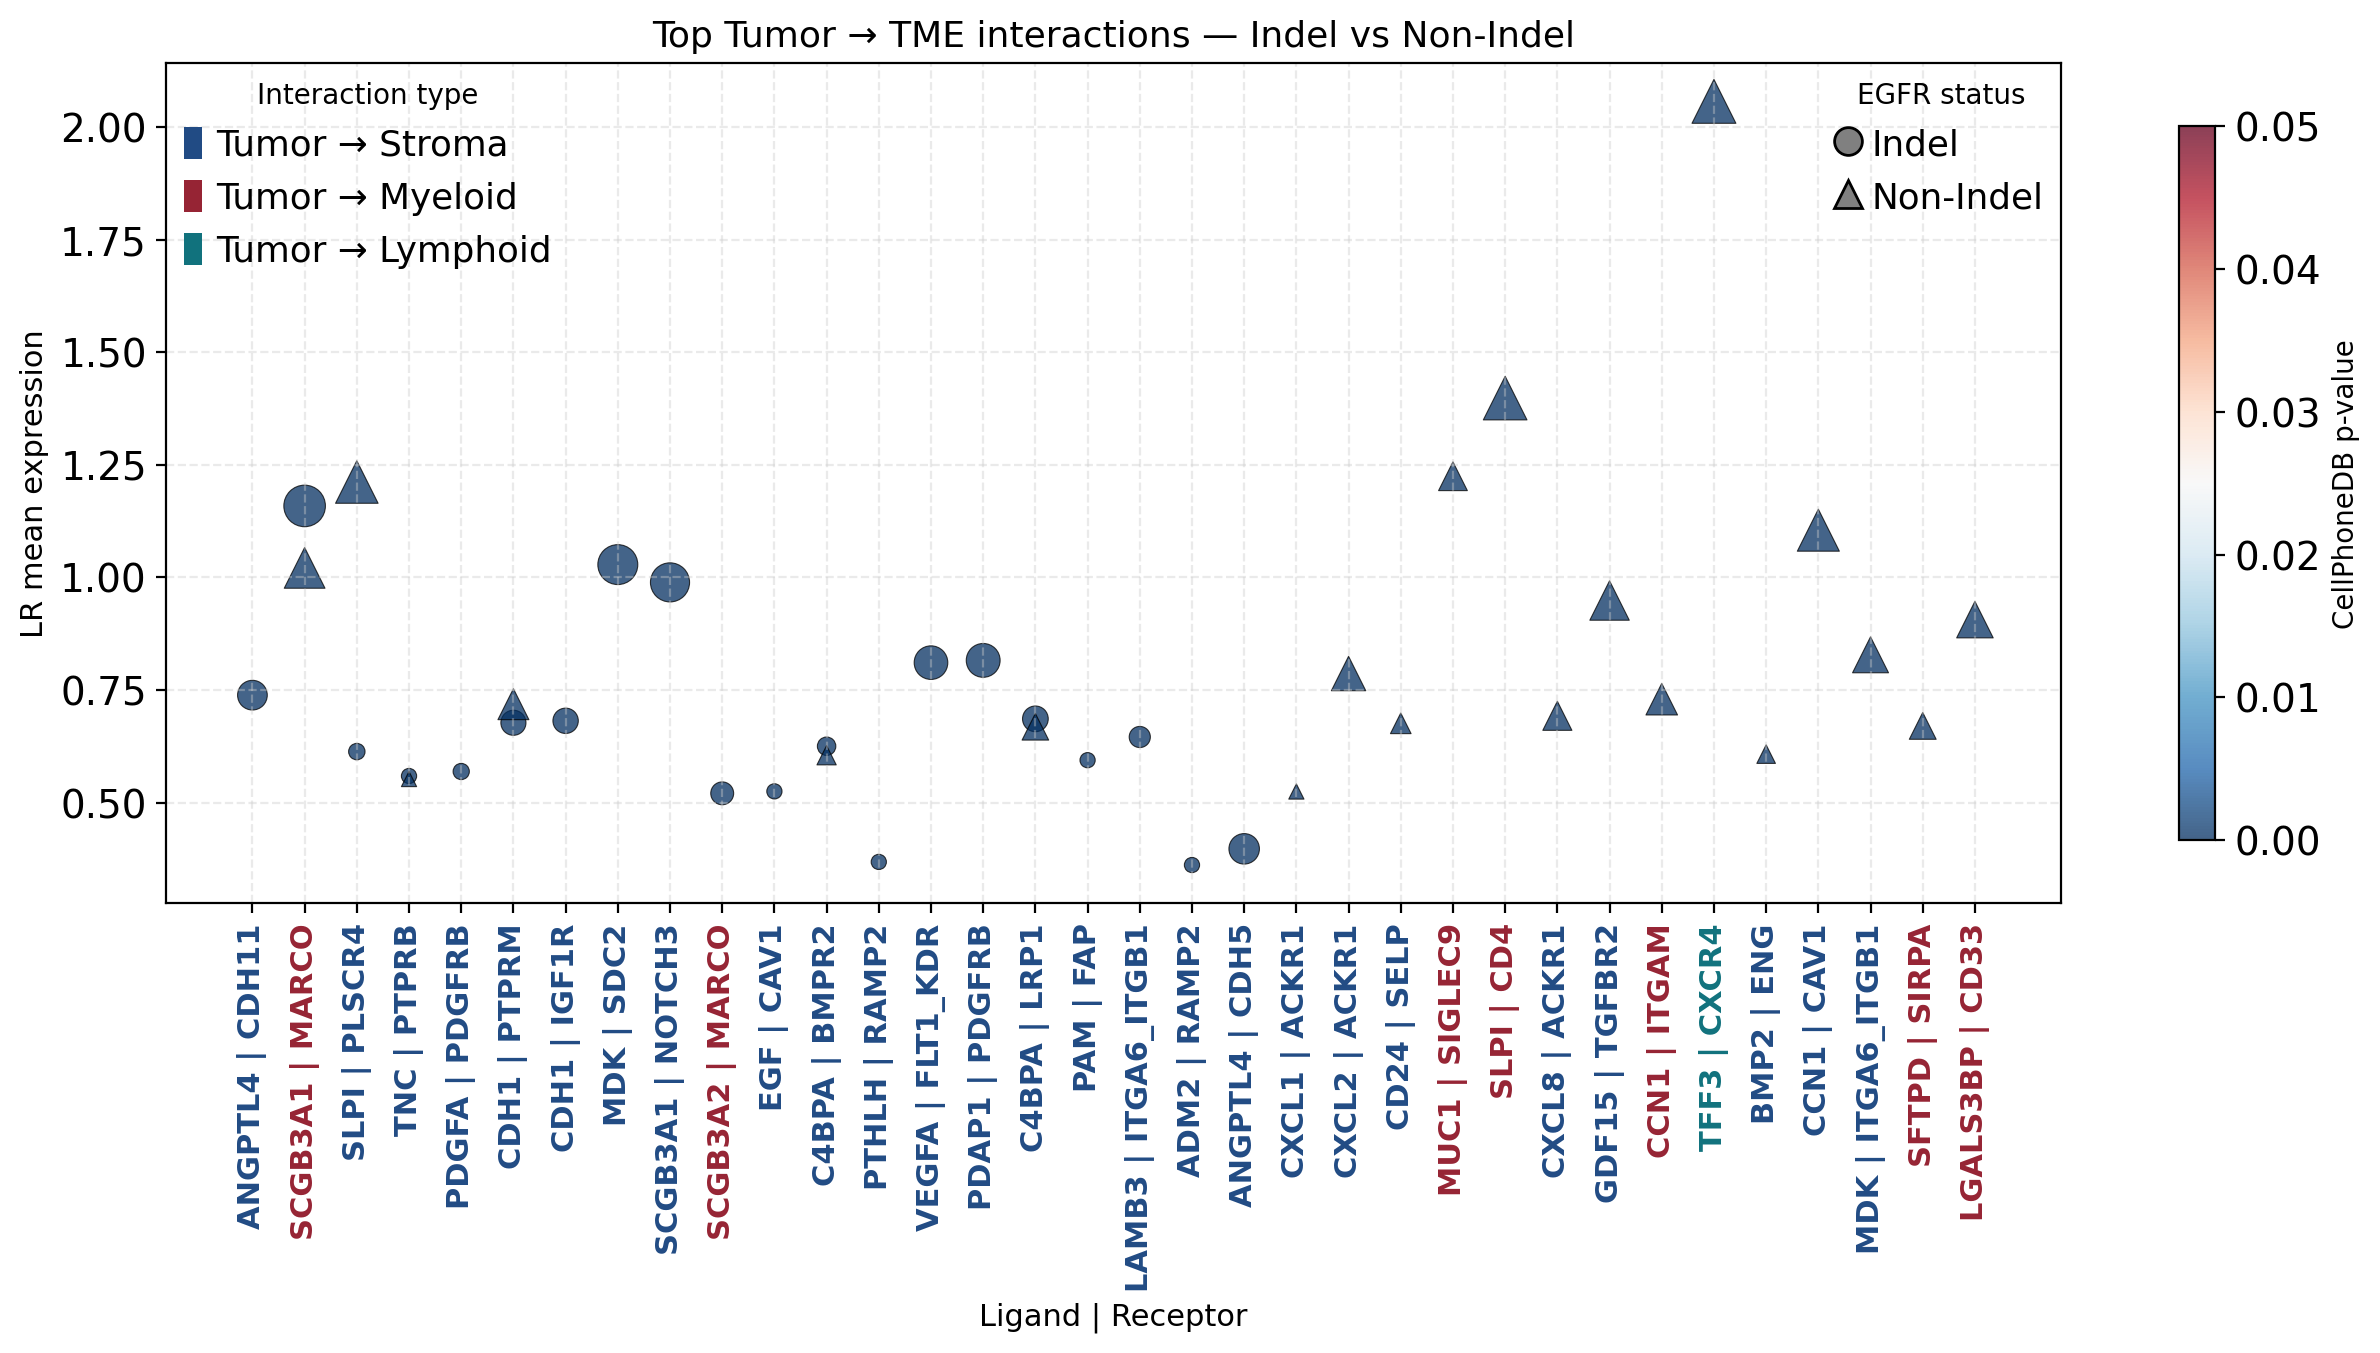

Indel: 20 interactions on plot
Non-Indel: 20 interactions on plot


In [7]:
liana_filt = full_liana_by_egfr_bin[
    (full_liana_by_egfr_bin['cellphone_pvals'] < 0.05) &
    (full_liana_by_egfr_bin['lr_means'] > 0)
].copy()

print(f"Significant interactions: {len(liana_filt)}")
print(liana_filt.groupby('egfr_status_bin').size())

liana_tumor_to_tme = liana_filt[
    (liana_filt['source'] == 'Tumor') &
    (liana_filt['target'] != 'Tumor')
].copy()

print(f'Total Tumor → TME interactions: {len(liana_tumor_to_tme)}')
print(liana_tumor_to_tme.groupby('egfr_status_bin').size())

compartment_to_category = {
    'Stroma': 'Tumor → Stroma',
    'Myeloid': 'Tumor → Myeloid',
    'Lymphoid': 'Tumor → Lymphoid',
}
category_colors = {
    'Tumor → Stroma':   '#214b84',
    'Tumor → Myeloid':  '#962434',
    'Tumor → Lymphoid': '#11727d',
}
default_color = '#3E2723'

def target_to_category(t):
    return compartment_to_category.get(t, f'Tumor → {t}')

tops = {}
for st in ['Indel', 'Non-Indel']:
    sub = liana_tumor_to_tme[liana_tumor_to_tme['egfr_status_bin'] == st].copy()
    if sub.empty:
        print(f'Skip {st}')
        continue
    top = sub.nsmallest(20, 'specificity_rank').copy()
    if top.empty:
        continue
    top['interaction'] = top['ligand_complex'] + ' | ' + top['receptor_complex']
    top['category'] = top['target'].apply(target_to_category)
    tops[st] = top

all_interactions = []
interaction_to_category = {}
for st in ['Indel', 'Non-Indel']:
    if st in tops:
        for lab, cat in zip(tops[st]['interaction'], tops[st]['category']):
            if lab not in all_interactions:
                all_interactions.append(lab)
                interaction_to_category[lab] = cat

marker_map = {'Indel': 'o', 'Non-Indel': '^'}

fig, ax = plt.subplots(figsize=(13, 7))

scatter_handles = []
for st, top in tops.items():
    sizes = top['magnitude_rank'].apply(lambda x: max(30, (1 - x) * 250))
    sc_plot = ax.scatter(
        top['interaction'],
        top['lr_means'],
        c=top['cellphone_pvals'],
        s=sizes,
        marker=marker_map[st],
        cmap='RdBu_r',
        vmin=0, vmax=0.05,
        alpha=0.75,
        edgecolors='black',
        linewidths=0.4,
    )
    scatter_handles.append(sc_plot)

cbar = plt.colorbar(scatter_handles[0], ax=ax, shrink=0.85)
cbar.set_label('CellPhoneDB p-value', fontsize=10)

ax.set_xticks(range(len(all_interactions)))
ax.set_xticklabels(all_interactions, rotation=90, fontsize=11, fontweight='bold')

for tick_label in ax.get_xticklabels():
    cat = interaction_to_category.get(tick_label.get_text(), None)
    tick_label.set_color(category_colors.get(cat, default_color))

ax.set_xlabel('Ligand | Receptor', fontsize=11)
ax.set_ylabel('LR mean expression', fontsize=11)
ax.set_title('Top Tumor → TME interactions — Indel vs Non-Indel', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

status_handles = [
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='grey',
                  markeredgecolor='black', markersize=10, label='Indel'),
    mlines.Line2D([], [], marker='^', color='w', markerfacecolor='grey',
                  markeredgecolor='black', markersize=10, label='Non-Indel'),
]
leg1 = ax.legend(handles=status_handles, title='EGFR status',
                 loc='upper right', frameon=False)
ax.add_artist(leg1)

present_categories = [c for c in category_colors if c in set(interaction_to_category.values())]
category_handles = [
    mpatches.Patch(facecolor=category_colors[c], edgecolor='none', label=c)
    for c in present_categories
]
ax.legend(handles=category_handles, title='Interaction type',
          loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('../figures/liana_top_tumor_to_tme_combined_egfr_bin.png', dpi=200, bbox_inches='tight')
plt.show()

for st, top in tops.items():
    print(f"{st}: {len(top)} interactions on plot")

## Pathway analysis via decoupleR

In [9]:
msigdb_h = pd.read_csv("../data//hallmark.csv")
reactome = pd.read_csv("../data/reactome.csv")

msigdb_h = msigdb_h.rename(columns={'geneset': 'source', 'genesymbol': 'target'})
reactome = reactome.rename(columns={'geneset': 'source', 'genesymbol': 'target'})
msigdb_h['weight'] = 1.0
reactome['weight'] = 1.0

print(f"Hallmark pathways: {msigdb_h['source'].nunique()}")
print(f"Reactome pathways: {reactome['source'].nunique()}")

compartments = ['Tumor', 'Myeloid', 'Lymphoid', 'Stroma']
egfr_groups = ['Indel', 'Non-Indel']
results = {}

for net, net_name in [(msigdb_h, 'Hallmark'), (reactome, 'Reactome')]:
    results[net_name] = {}
    
    for comp in compartments:
        sub = adata[
            (adata.obs['cell_group'] == comp) &
            (adata.obs['egfr_status_bin'].isin(egfr_groups))
        ].copy()
        
        if sub.n_obs < 50:
            print(f"Пропускаем {comp} ({net_name}): мало клеток ({sub.n_obs})")
            continue
        
        print(f"Считаем {net_name} / {comp}: {sub.n_obs} клеток")
        
        dc.mt.ulm(data=sub, net=net, verbose=False)
        
        acts = dc.pp.get_obsm(sub, key='score_ulm')
        acts.obs['egfr_status_bin'] = sub.obs['egfr_status_bin'].values
        results[net_name][comp] = acts

print("Готово.")

pairs = list(itertools.combinations(egfr_groups, 2))
summary_tables = {}

for net_name, comp_dict in results.items():
    rows = []
    for comp, acts in comp_dict.items():
        df = pd.DataFrame(acts.X, columns=acts.var_names, index=acts.obs_names)
        df['egfr_status_bin'] = acts.obs['egfr_status_bin'].values
        
        for g1, g2 in pairs:
            d1 = df[df['egfr_status_bin'] == g1].drop(columns='egfr_status_bin')
            d2 = df[df['egfr_status_bin'] == g2].drop(columns='egfr_status_bin')
            
            for pw in d1.columns:
                v1 = d1[pw].dropna()
                v2 = d2[pw].dropna()
                if len(v1) < 5 or len(v2) < 5:
                    continue
                stat, pval = mannwhitneyu(v1, v2, alternative='two-sided')
                rows.append({
                    'compartment': comp,
                    'pathway': pw,
                    'comparison': f'{g1}_vs_{g2}',
                    f'mean_{g1}': v1.mean(),
                    f'mean_{g2}': v2.mean(),
                    'delta': v1.mean() - v2.mean(),
                    'pval': pval
                })
    
    res_df = pd.DataFrame(rows)
    if not res_df.empty:
        _, res_df['padj'], _, _ = multipletests(res_df['pval'], method='fdr_bh')
        res_df = res_df.sort_values('padj')
        print(f"\n{net_name}: значимых pathway (padj<0.05): {(res_df['padj']<0.05).sum()}")
    else:
        print(f"\n{net_name}: пустой результат")
    summary_tables[net_name] = res_df

Hallmark pathways: 50
Reactome pathways: 14


Считаем Hallmark / Tumor: 22163 клеток
Считаем Hallmark / Myeloid: 24193 клеток
Считаем Hallmark / Lymphoid: 48610 клеток
Считаем Hallmark / Stroma: 4010 клеток
Считаем Reactome / Tumor: 22163 клеток
Считаем Reactome / Myeloid: 24193 клеток
Считаем Reactome / Lymphoid: 48610 клеток
Считаем Reactome / Stroma: 4010 клеток
Готово.

Hallmark: значимых pathway (padj<0.05): 182

Reactome: значимых pathway (padj<0.05): 48


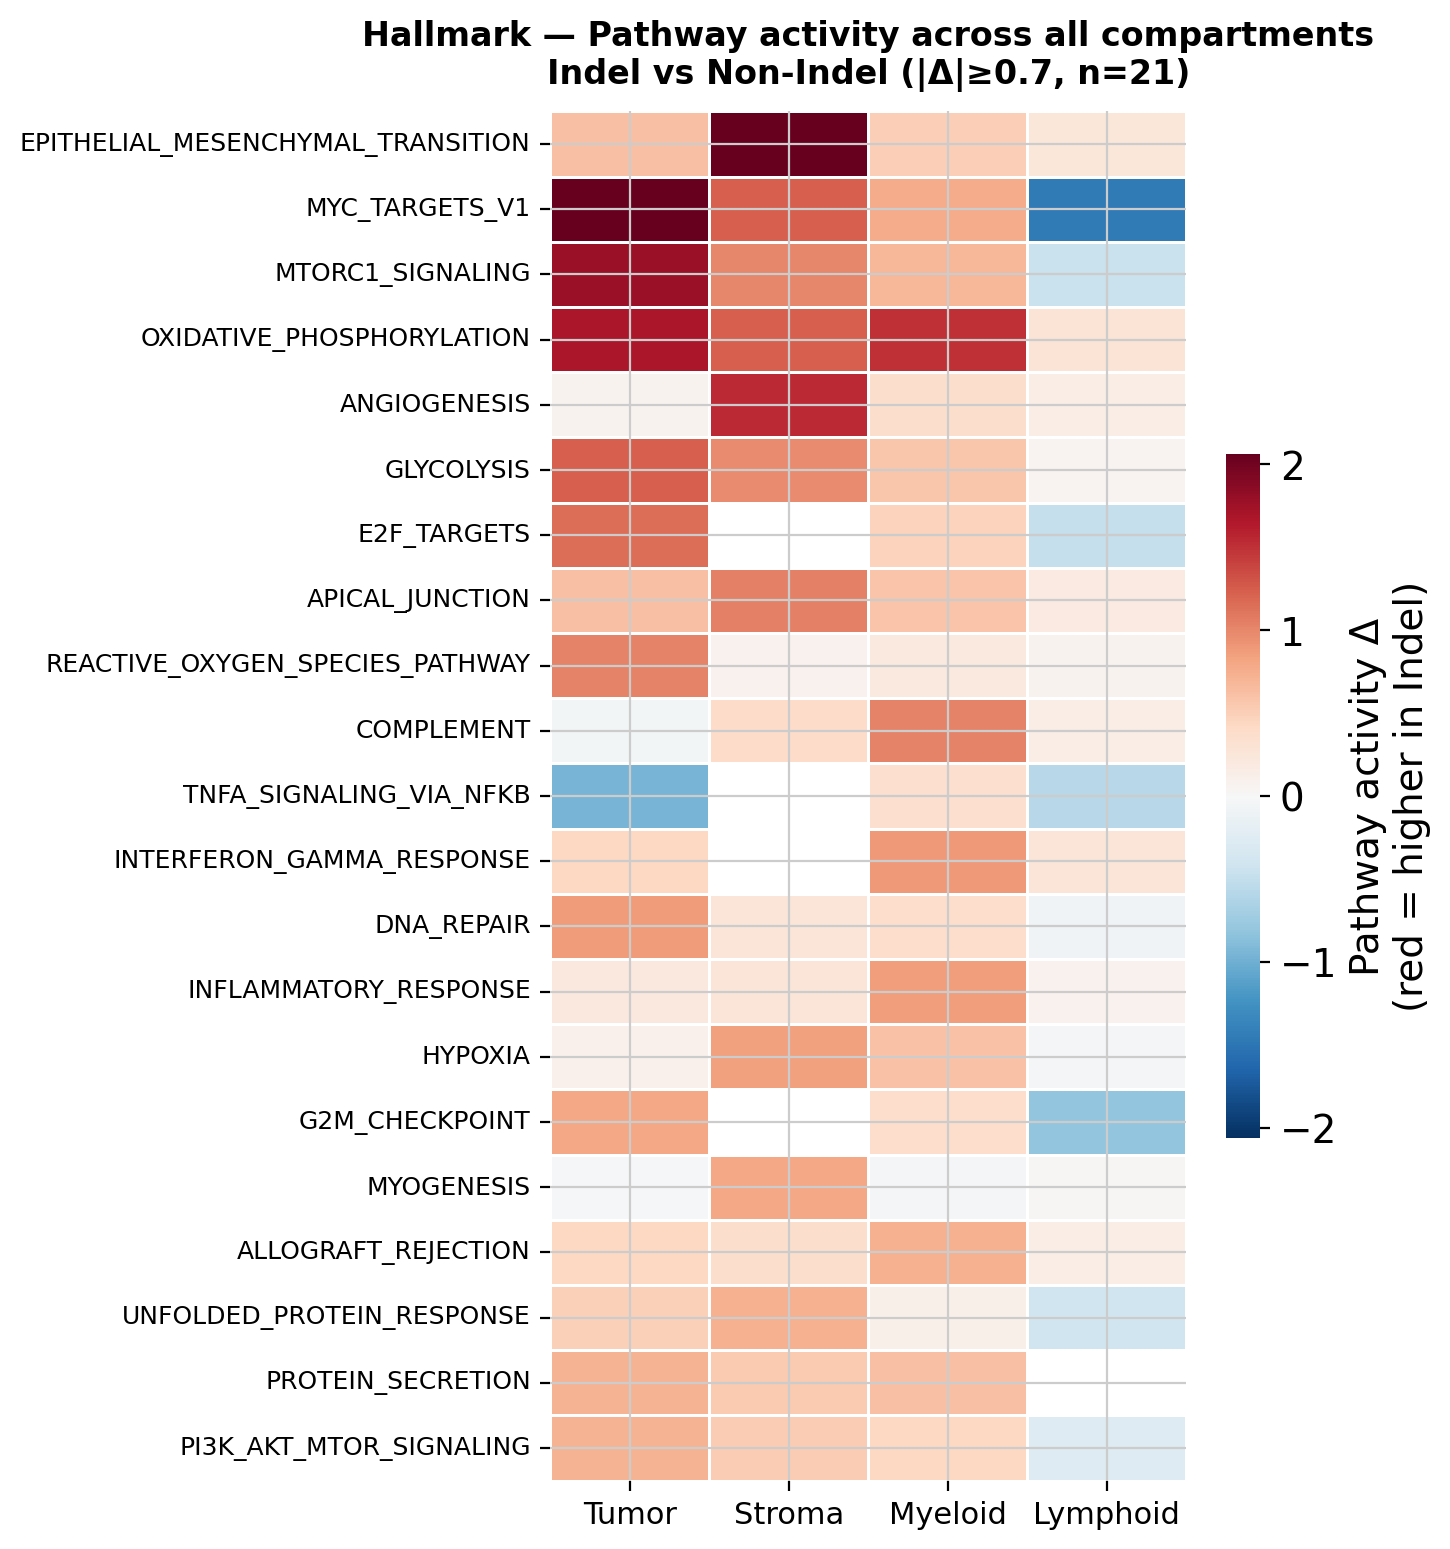

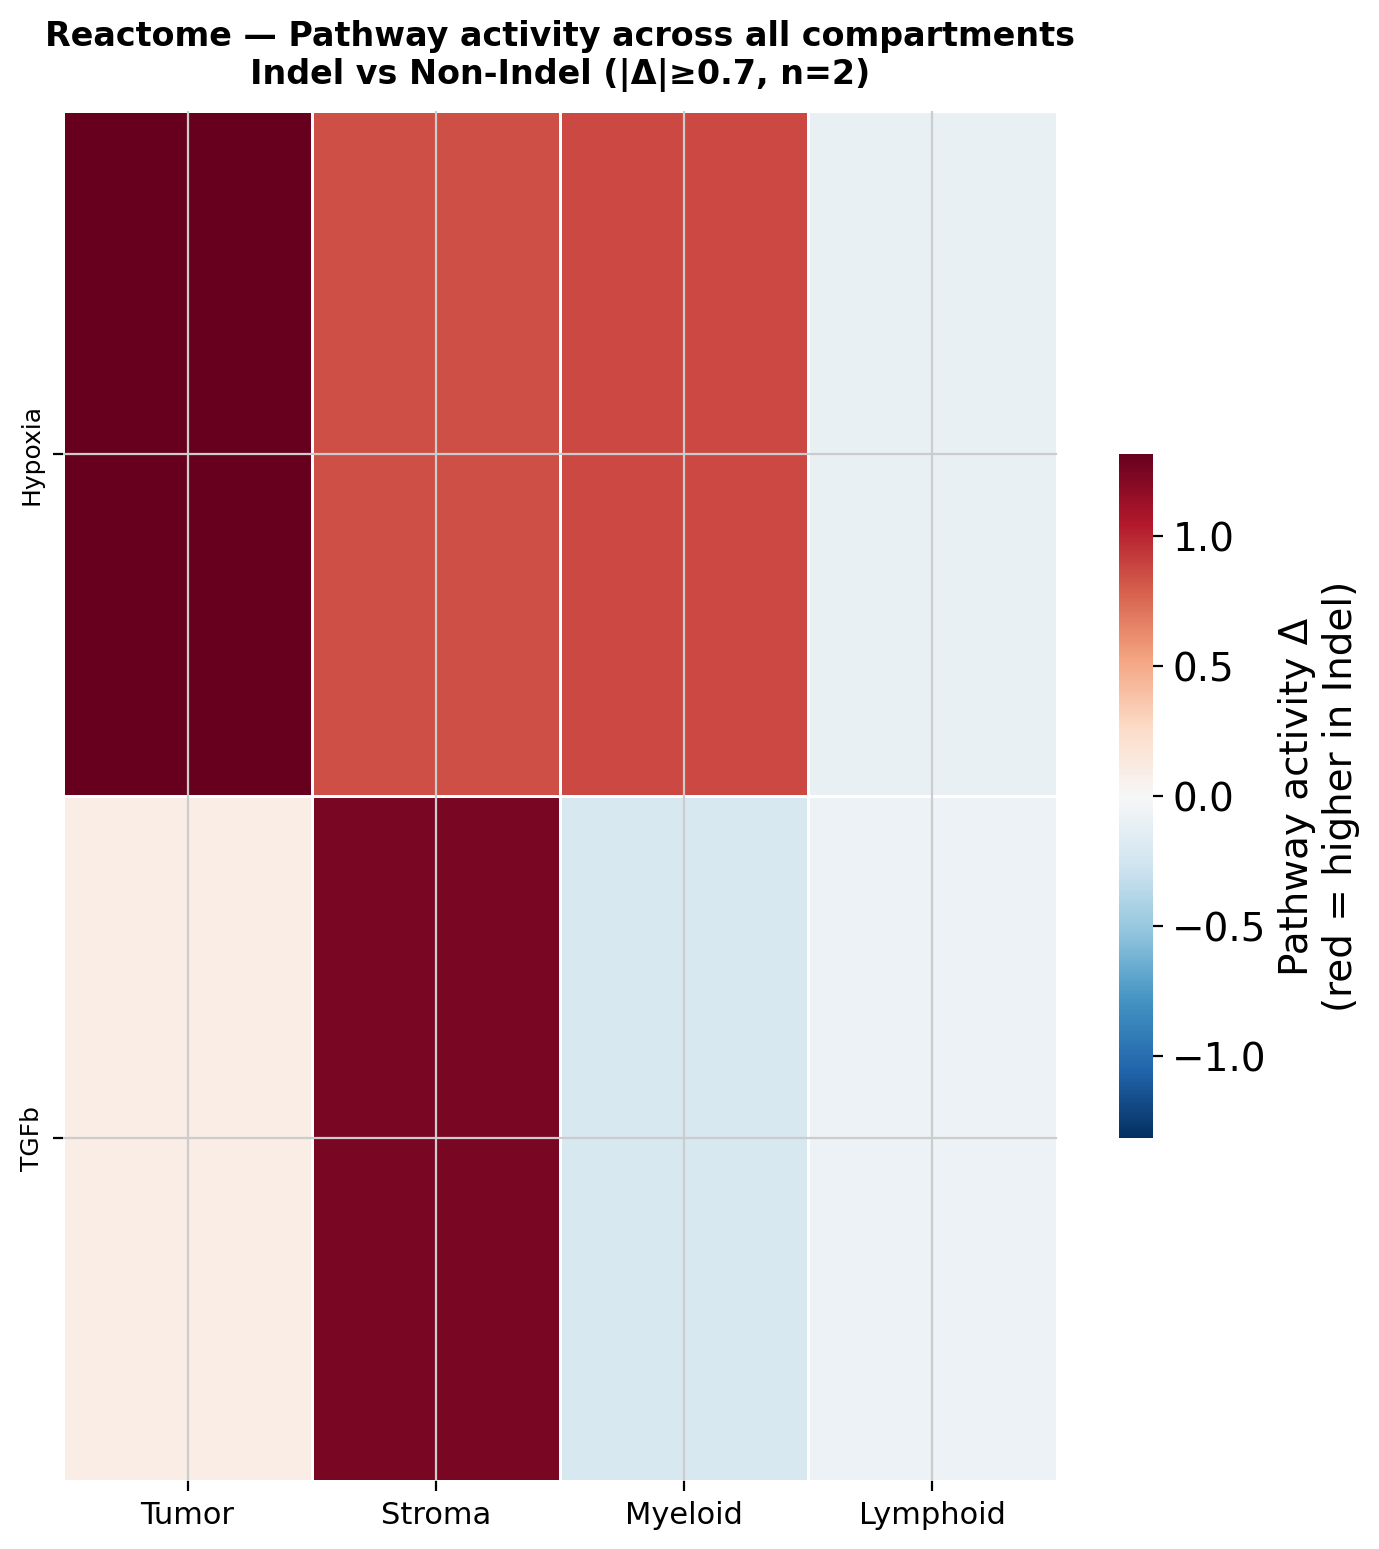

In [10]:
for net_name, res_df in summary_tables.items():
    if res_df.empty:
        continue
    sig = res_df[res_df['padj'] < 0.05].copy()
    if sig.empty:
        continue
    
    sig['abs_delta'] = sig['delta'].abs()
    
    pw_max_abs = sig.groupby('pathway')['abs_delta'].max()
    strong_pw = pw_max_abs[pw_max_abs >= 0.7].sort_values(ascending=False).index.tolist()
    
    if not strong_pw:
        print(f'{net_name}: нет pathways с |Δ|>=0.7')
        continue
    
    sub_overall = sig[sig['pathway'].isin(strong_pw)]
    pivot_overall = sub_overall.pivot_table(
        index='pathway', columns='compartment', values='delta'
    )
    col_order = [c for c in ['Tumor', 'Stroma', 'Myeloid', 'Lymphoid'] if c in pivot_overall.columns]
    pivot_overall = pivot_overall[col_order]
    pivot_overall = pivot_overall.loc[
        pivot_overall.abs().max(axis=1).sort_values(ascending=False).index
    ]
    
    n_rows = len(pivot_overall)
    n_cols = len(col_order)
    fig, ax = plt.subplots(figsize=(1.3 * n_cols + 2, max(8, n_rows * 0.32)))
    vmax = np.nanpercentile(np.abs(pivot_overall.values), 98)
    sns.heatmap(
        pivot_overall, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        linewidths=0.5, linecolor='white', ax=ax,
        cbar_kws={'label': 'Pathway activity Δ\n(red = higher in Indel)', 'shrink': 0.5},
        square=False,
    )
    ax.set_title(
        f'{net_name} — Pathway activity across all compartments\n'
        f'Indel vs Non-Indel (|Δ|≥0.7, n={n_rows})',
        fontsize=12, fontweight='bold', pad=10
    )
    ax.set_xlabel(''); ax.set_ylabel('')
    plt.xticks(rotation=0, fontsize=11)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.savefig(f'../figures/pathway_heatmap_{net_name}_all_compartments_egfr_bin.png',
                dpi=200, bbox_inches='tight')
    plt.show()